In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## RuWordNet
 Структура объектов в RuWordNet:
Sense — смысловая единица (одно значение слова).

sense.lexeme → Lexeme — лексема (информация о слове).

sense.synset → Synset — синсет (группа синонимов).

Lexeme — словоформа (содержит lemma, pos, freq, source, и др.).

Synset — синонимический набор (содержит lexemes, relations, premises, definition и т.д.).

In [ ]:
! pip install ruwordnet

In [5]:
! ruwordnet download


downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [11]:
from ruwordnet import RuWordNet
wn = RuWordNet()

In [7]:
len(wn.synsets), len(wn.senses)

(59905, 154111)

# Using the thesaurus

In [8]:
for sense in wn.get_senses('замок'):
    print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [9]:
wn.get_senses('замок')[0].synset.hypernyms

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [10]:
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [11]:
wn.get_senses('авокадо')

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

In [12]:
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0]
veg

Synset(id="348-N", title="ОВОЩИ")

In [13]:
veg.hyponyms

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

## More relations

Домен - атрибут

In [ ]:
print(wn['мяч'][0].synset.domains) #получает список лексических единиц (Lexeme), связанных со словом
#синсет (множество синонимичных слов)

[Synset(id="109383-N", title="ИГРА (РАЗВЛЕЧЕНИЕ)"), Synset(id="1622-N", title="СПОРТ")]


In [16]:
import random
print(random.sample(wn['спорт'][0].synset.domain_items, 10))

[Synset(id="137156-A", title="ТОВАРИЩЕСКИЕ СОРЕВНОВАНИЯ"), Synset(id="126815-V", title="ПРЫЖКИ НА ЛЫЖАХ С ТРАМПЛИНА"), Synset(id="108790-N", title="КАНОЭ"), Synset(id="150218-N", title="ЛИДЕР СОРЕВНОВАНИЯ"), Synset(id="137737-N", title="АКРОБАТИЧЕСКИЙ ТРЮК"), Synset(id="112757-N", title="ТЯЖЕЛОАТЛЕТ"), Synset(id="145218-N", title="СПОРТИВНО-ОЗДОРОВИТЕЛЬНОЕ УЧРЕЖДЕНИЕ"), Synset(id="152052-A", title="СКЕЛЕТОН (ВИД СПОРТА)"), Synset(id="139229-N", title="СПОРТИВНОЕ ОРИЕНТИРОВАНИЕ"), Synset(id="10040-A", title="ГАНДБОЛ")]


Часть - целое

In [17]:
print(wn['автомобиль'][0].synset.meronyms)

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"), Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"), Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"), Synset(id="108798-N", title="КАПОТ МАШИНЫ")]


In [18]:
print(wn['страница'][0].synset.holonyms)

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"), Synset(id="5820-N", title="ТЕТРАДЬ")]


Класс-экземпляр

In [19]:
print(wn['москва-река'][0].synset.classes)

[Synset(id="136791-N", title="РЕКИ РОССИЙСКОЙ ФЕДЕРАЦИИ")]


In [20]:
print(random.sample(wn['областной центр'][0].synset.instances, 10))

[Synset(id="102478-N", title="ПСКОВ"), Synset(id="100628-N", title="ВОЛГОГРАД"), Synset(id="101115-N", title="КАЛИНИНГРАД"), Synset(id="100328-N", title="АРХАНГЕЛЬСК"), Synset(id="102373-N", title="ПЕНЗА"), Synset(id="100577-N", title="ВЛАДИМИР (ГОРОД)"), Synset(id="101875-N", title="МАГАДАН"), Synset(id="102337-N", title="ОРЕЛ (ГОРОД)"), Synset(id="101001-N", title="ИВАНОВО"), Synset(id="102849-N", title="ТВЕРЬ")]


Предпосылки - выводы

In [35]:
print(wn['колоть'][0].synset.premises) #.premises — это дополнительные семантические утверждения или метаинформация 

[]


In [33]:
print(wn['завоевать'][0].synset.conclusions)

[Synset(id="106961-V", title="СОРЕВНОВАНИЕ, СОСТЯЗАНИЕ")]


Причины-следствия

In [36]:
print(wn['устать'][0].synset.causes)

[Synset(id="114599-V", title="УТОМИТЬ")]


In [ ]:
print(wn['убить'][0].synset.effects) # это поле, в котором хранятся семантические эффекты (последствия) действия

[]


Частеречные синонимы

In [38]:
[s for ss in wn['убить'][0].synset.pos_synonyms for s in ss.senses]

[Sense(id="4628-N-113272", name="УБИЙСТВО"),
 Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ"),
 Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО"),
 Sense(id="4628-N-193509", name="МОКРУХА"),
 Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО"),
 Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО"),
 Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА"),
 Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")]

антонимы

In [39]:
wn['быстрый'][0].synset.antonyms

[Synset(id="118957-A", title="МЕДЛЕННЫЙ, НЕБЫСТРЫЙ")]

фразы и их составляющие

In [40]:
wn['быстрый'][0].phrases

[Sense(id="102679-N-129996", name="РЕКА БЫСТРАЯ"),
 Sense(id="8930-N-117128", name="БЫСТРОЕ ПИТАНИЕ"),
 Sense(id="9241-N-118631", name="БЫСТРЫЕ ШАХМАТЫ")]

In [ ]:
wn['послужной список'][0].words

[Sense(id="106989-N-153921", name="СПИСОК")]

Однокоренные слова

In [41]:
wn['синий'][0].derivations

[Sense(id="109476-A-205236", name="СИНЕВАТЫЙ"),
 Sense(id="109476-A-689608", name="СИНЕНЬКИЙ"),
 Sense(id="109476-N-152798", name="СИНЕВА"),
 Sense(id="109476-N-152826", name="СИНЬ"),
 Sense(id="110418-N-148452", name="ПОСИНЕНИЕ"),
 Sense(id="110418-V-148453", name="ПОСИНЕТЬ"),
 Sense(id="110418-V-152799", name="СИНЕТЬ"),
 Sense(id="110419-V-152806", name="СИНИТЬ"),
 Sense(id="110419-V-175408", name="ПОДСИНИВАТЬ"),
 Sense(id="110765-N-152827", name="СИНЬКА"),
 Sense(id="111011-V-152799", name="СИНЕТЬ"),
 Sense(id="111011-V-183154", name="ЗАСИНЕТЬ")]

# Predicting hypernyms

In [2]:
!pip uninstall -y numpy
!pip install numpy==1.23.5
!pip install --force-reinstall --no-cache-dir gensim


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.6 MB 4.2 MB/s eta 0:00:04
   ------- -------------------------------- 2.9/14.6 MB 9.9 MB/s eta 0:00:02
   -------- ------------------------------- 3.1/14.6 MB 10.3 MB/s eta 0:00:02
   --------------- ------------------------ 5.8/14.6 MB 9.3 MB/s eta 0:00:01
   --------------------- ------------------ 7.9/14.6 MB 9.0 MB/s eta 0:00:01
   ------------------------- -------------- 9.4/14.6 MB 8.8 MB/s eta 0:00:01
   ------------------------------- -------- 11.5/14.6 MB 9.0 MB/s eta 0:00:01
   ------------------------------------ --- 13.4/14.6 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------  14.4/14.6 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------  14

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyldavis 3.4.1 requires gensim, which is not installed.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 1.23.5 which is incompatible.
pyldavis 3.4.1 requires numpy>=1.24.2, but you have numpy 1.23.5 which is incompatible.
pyldavis 3.4.1 requires pandas>=2.0.0, but you have pandas 1.5.3 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.0 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.0 MB 3.0 MB/s eta 0:00:08
   -- ------------------------------------- 1.6/24.0 MB 2.7 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/24.0 MB 2.6 MB/s eta 0:00:09
   --- ------------------------------------ 2.4/24.0 MB 2.6 MB/s eta 0:00:09
   ----- ---------------------------------- 3.1/24.0 MB 2.6 MB/s eta 0:00:09
   ------ --------------------------------- 3.7/24.0 MB 2.6 MB/s eta 0:00:08
   ------ --------------------------------- 3.9/24.0 MB 2.6 MB/s eta 0:00:08
   ------- -------------------------------- 4.5/24.0 MB 2.5 MB/s eta 0:00:08
   -------- ------------------------------- 5.0/24.0 MB 2.4 MB/s eta 0:00:08
   -------- ------------------------------- 5.2/24.0 MB 2.3 MB/s eta 0:00:09
   ---------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyldavis 3.4.1 requires pandas>=2.0.0, but you have pandas 1.5.3 which is incompatible.


In [3]:
!pip install --upgrade git+https://github.com/avidale/compress-fasttext.git


Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/avidale/compress-fasttext.git to c:\users\alena\appdata\local\temp\pip-req-build-l8d3oa1a
  Resolved https://github.com/avidale/compress-fasttext.git to commit 78f13cf7cd1924a1eb64d4931094225c1b6e7dbc
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for compress-fasttext: filename=compress_fasttext-0.1.5-py3-none-any.whl size=16223 sha256=865bdeeecbed5a440984efeb0d34dbd2f2e7e37f44f80076c674bc8259d5bf59
  Stored in directory: C:\Users\alena\AppData\Local\Temp\pip-ephem-wheel-cache-179e8txp\wheels\d1\ac\2b\96d3cf51b117a0c065424417b69683d514648493a76bcbfb86
Successfully built compress-fasttext


  Running command git clone --filter=blob:none --quiet https://github.com/avidale/compress-fasttext.git 'C:\Users\alena\AppData\Local\Temp\pip-req-build-l8d3oa1a'
  DEPRECATION: Building 'compress-fasttext' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'compress-fasttext'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [ ]:
import numpy as np
# библиотека для сжатия моделей fasttext
# github: https://github.com/avidale/compress-fasttext?tab=readme-ov-file


from collections import Counter
from sklearn.neighbors import KDTree

import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
import compress_fasttext

ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)


In [7]:
def vectorize(text):
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0)
    vec /= sum(vec**2) ** 0.5 
    return vec

def distance2vote(d, a=3, b=5):
    sim = np.maximum(0, 1 - d**2/2)
    return np.exp(-d**a) * sim **b

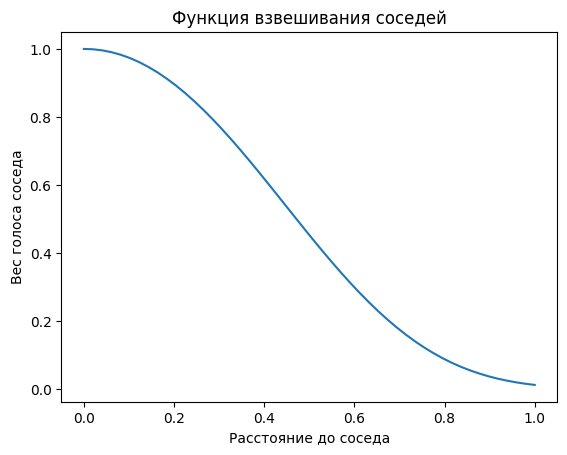

In [8]:
x = np.linspace(0, 1)
plt.plot(x, distance2vote(x))
plt.xlabel('Расстояние до соседа')
plt.ylabel('Вес голоса соседа')
plt.title('Функция взвешивания соседей');

In [9]:
from tqdm.auto import tqdm, trange

C:\Users\alena\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
words, vectors, synset_ids = [], [], []
for synset in tqdm(wn.synsets):
    if synset.part_of_speech != 'V':
        continue
    for sense in synset.senses:
        words.append(sense.name)
        vectors.append(vectorize(sense.name))
        synset_ids.append(synset.id)
vectors = np.stack(vectors)
tree = KDTree(vectors)

100%|██████████| 59905/59905 [09:08<00:00, 109.21it/s]  


In [13]:
votes = Counter()
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100)
for idx, distance in zip(ids[0], dists[0]):
    for hyper in wn[synset_ids[idx]].hypernyms:
        votes[hyper.id] += distance2vote(distance)
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms])

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['БОРМОТАТЬ']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ РУКОЙ, ЗУБАМИ, ОРУДИЕМ']
БРАТЬСЯ ['П

In [14]:
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


# Найди лишнее 
ДИВАН, ШКАФ, ЛАМПА, СТОЛ

In [15]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    front = [sense.synset for sense in wn.get_senses(word)]
    levels = {}
    for level in range(max_level):
        if not front:
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                levels[synset.id] = level
                new_front.extend(synset.hypernyms)
        front = new_front
    return levels

def get_closest_common(levels1, levels2):
    """ Find the closest common hypernym and sum of distances to it"""
    result = None
    result_distance = math.inf
    for id, distance in levels1.items():
        if id in levels2:
            total = distance + levels2[id]
            if total < result_distance:
                result_distance = total
                result = id
    return result, result_distance

In [16]:
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']
print('\t\t', '\t'.join(words))
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


In [17]:
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [18]:
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


In [19]:
wn["149201-N"].hypernyms

[Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО"),
 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")]

In [20]:
for k, v in get_all_hypernyms(wn, 'стол').items():
    print(k, v, wn[k])

146834-N 0 Synset(id="146834-N", title="СТОЛ ДЛЯ ЕДЫ")
107294-N 0 Synset(id="107294-N", title="СТОЛ")
106554-N 1 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
1253-N 1 Synset(id="1253-N", title="МЕБЕЛЬ")
147133-N 2 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
130019-N 2 Synset(id="130019-N", title="НЕПРОДОВОЛЬСТВЕННЫЕ ТОВАРЫ")
146828-N 2 Synset(id="146828-N", title="ПРЕДМЕТ ИНТЕРЬЕРА")
9059-N 2 Synset(id="9059-N", title="ПРОДУКЦИЯ ДЕРЕВООБРАБОТКИ")
147134-N 3 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
1252-N 3 Synset(id="1252-N", title="ПОТРЕБИТЕЛЬСКИЕ ТОВАРЫ")
56-N 3 Synset(id="56-N", title="ПРОМЫШЛЕННАЯ ПРОДУКЦИЯ")
562-N 3 Synset(id="562-N", title="ТОВАР")
106507-N 3 Synset(id="106507-N", title="ПРОДУКТ ПРОИЗВОДСТВА")
153782-N 4 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")
106505-N 4 Synset(id="106505-N", title="ПРОДУКТ ТРУДА")


# Word sense disambiguation 

зАмок или замОк ?

Примитивный алгоритм: для каждого значения находим синонимы и проверяем, какие ближе по fasttext-эмбеддингу к словам контекста.

Для верности, стоило бы кроме синонимов взять ещё и ко-гипонимы. 

In [21]:
import razdel

In [22]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок 
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [23]:
def disambiguate(word, context):
    candidates = [s.synset for s in wn[word]]
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word))
    candidate_vectors = [
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates
    ]
    scores = [np.dot(text_vector, v) for v in candidate_vectors]
    return dict(zip(scores, candidates))

disambiguate(word, context)

{0.4421322748905842: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.55319632362594: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

In [24]:
context = '''Издали видны королевский замок Вавель и кафедральный собор Святых Вацлава и Станислава 
― настоящие шедевры зодчества.'''
disambiguate(word, context)

{0.6623339070392336: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.5569728387813148: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}